In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
sz = "124M"

loss_baseline = {
    "124M": 3.2924,
}[sz]
hella2_baseline = {
    "124M": 0.294463,
    "350M": 0.375224,
    "774M": 0.431986,
    "1558M": 0.488946,
}[sz]

with open('./log/log.txt', 'r') as file:
    lines = file.readlines()

scores = {}
for line in lines:
    ep, mode, val = line.strip().split()
    scores[mode] = scores.get(mode, {})
    scores[mode][int(ep)] = float(val)

scores_xy = {}
for k, v in scores.items():
   xy = sorted(list(v.items()))
   scores_xy[k] = list(zip(*xy))

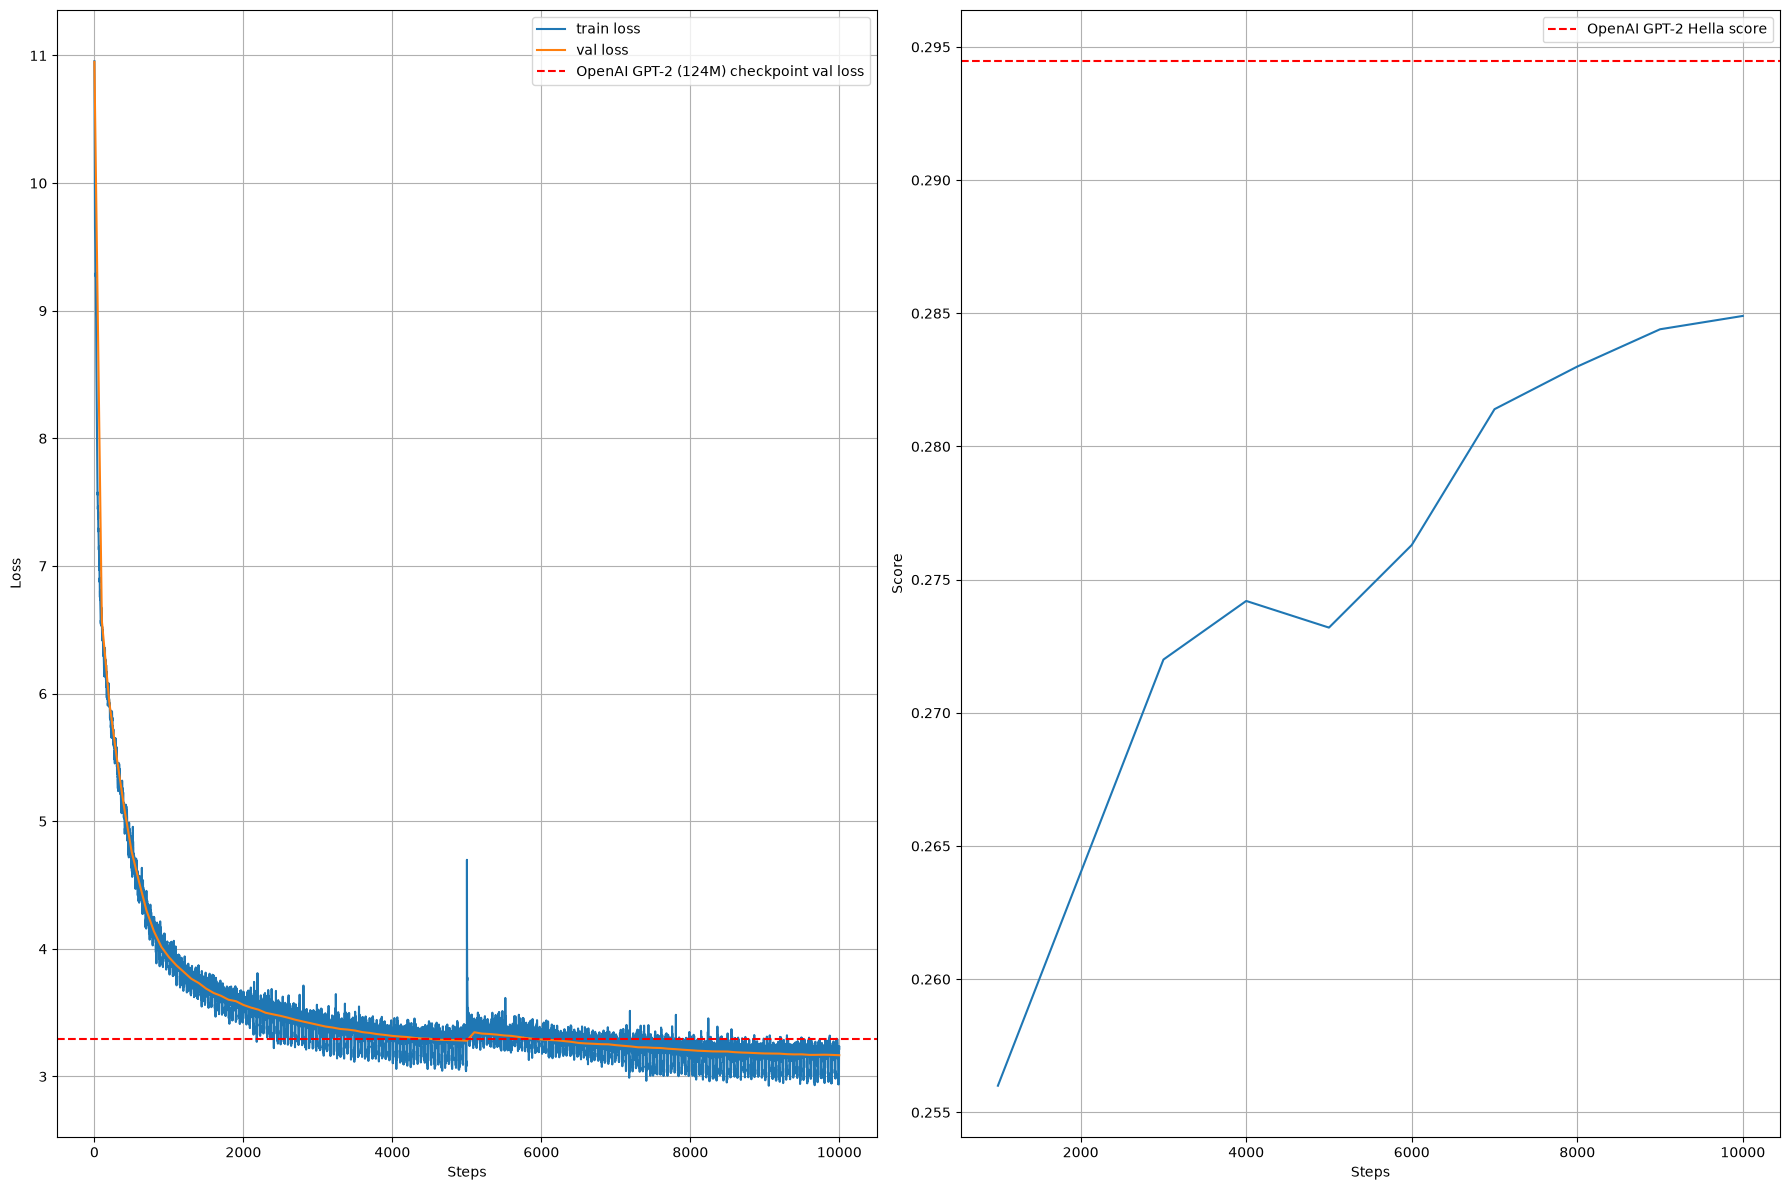

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 12))
axes = axes.flatten()
xs, ys = scores_xy['val']
xs_train, ys_train = scores_xy['train']

axes[0].plot(xs_train, ys_train, label='train loss')
axes[0].plot(xs, ys, label='val loss')
axes[0].axhline(y=loss_baseline, color='r', linestyle='--', label=f"OpenAI GPT-2 ({sz}) checkpoint val loss")

axes[0].legend()
axes[0].grid(True)
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Loss')

hella_steps, hella_vals = scores_xy['hella']
axes[1].plot(hella_steps, hella_vals)
axes[1].axhline(y=hella2_baseline, color='r', linestyle='--', label=f"OpenAI GPT-2 Hella score")
axes[1].legend()
axes[1].grid(True)
axes[1].set_xlabel('Steps')
axes[1].set_ylabel('Score')

plt.tight_layout()

#### We trained our model on nearly 2 times lesser number of steps, but already achieved good results, close enough to the original paper